# ML Lab - EDA Pipeline (Exp1)

## i) Loading the dataset ii) Exploratory Data Analysis and Visualization iii) Data Preprocessing

#### Importing Required Libraries

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder
#import torch
#import torch.nn as nn
#import torch.optim as optim
#from torch.utils.data import DataLoader, TensorDataset
#import tensorflow as tf
#from tensorflow import keras
#from tensorflow.keras import layers, models, Sequential

#### Dataset Retreival

In [95]:
file = input("Enter the path: ")
if file.endswith(".csv"):
    df=pd.read_csv(file)
elif file.endswith(".xlsx"):
    df=pd.read_excel(file)
#elif file.endswith(".data"):
    #df = pd.read_csv(".data)
else:
    raise ValueError("Only CSV and Excel files are supported.")

Enter the path:  /home/mtech2/ML_Lab/loan_approval_dataset.csv


In [96]:
print(df.head(5))
print(df.describe())
print(df.info())
print(df.dtypes)

   loan_id   no_of_dependents      education  self_employed   income_annum  \
0        1                  2       Graduate             No        9600000   
1        2                  0   Not Graduate            Yes        4100000   
2        3                  3       Graduate             No        9100000   
3        4                  3       Graduate             No        8200000   
4        5                  5   Not Graduate            Yes        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commercial_assets_value   luxury_assets_value   bank_asset_value  \
0                  1760000

#### Missing Values

In [97]:
print("\nMISSING VALUES")
missing = df.isnull().sum()
print(missing)

if missing.sum() > 0:
    plt.figure(figsize=(8,4))
    missing[missing > 0].sort_values().plot(kind='barh')
    plt.title("Missing Values")
    plt.xlabel("Count")
    plt.show()


MISSING VALUES
loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64


#### Duplicate Rows

In [98]:
duplicates = df.duplicated().sum()
print("\nDuplicate Rows :", duplicates)



Duplicate Rows : 0


#### Unique Values

In [99]:
print("\nUNIQUE VALUES")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")


UNIQUE VALUES
loan_id: 4269
 no_of_dependents: 6
 education: 2
 self_employed: 2
 income_annum: 98
 loan_amount: 378
 loan_term: 10
 cibil_score: 601
 residential_assets_value: 278
 commercial_assets_value: 188
 luxury_assets_value: 379
 bank_asset_value: 146
 loan_status: 2


#### Numerical Columns and Categorical Columns

In [100]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("\nNumerical Columns")
print(num_cols)

print("\nCategorical Columns")
print(cat_cols)


Numerical Columns
['loan_id', ' no_of_dependents', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value']

Categorical Columns
[' education', ' self_employed', ' loan_status']


### Count Plot


Value Counts for  education
 education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64


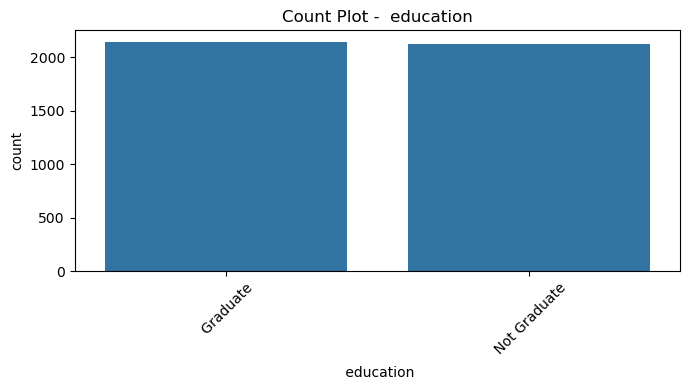


Value Counts for  self_employed
 self_employed
Yes    2150
No     2119
Name: count, dtype: int64


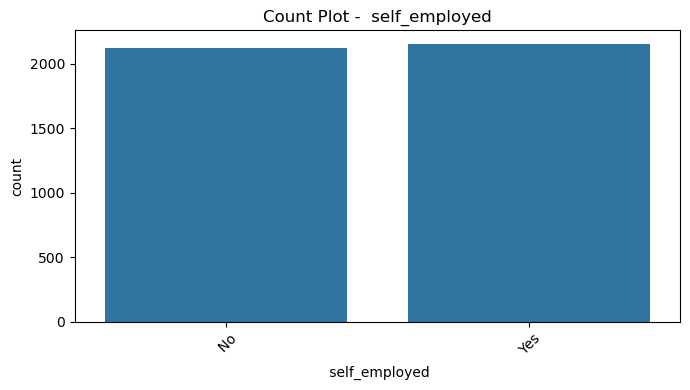


Value Counts for  loan_status
 loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


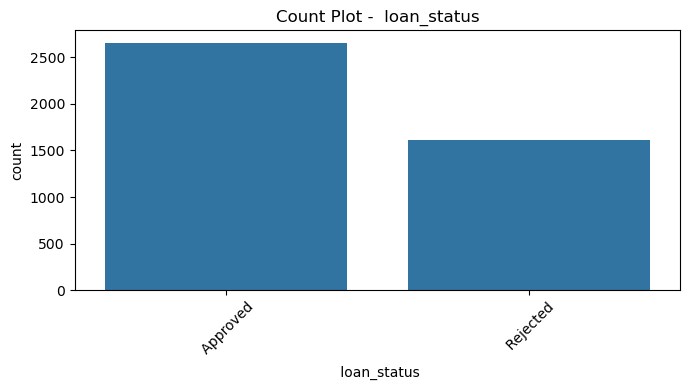

In [101]:
for col in cat_cols:

    print(f"\nValue Counts for {col}")
    print(df[col].value_counts())

    plt.figure(figsize=(7,4))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(f"Count Plot - {col}")
    plt.tight_layout()
    plt.show()

#### Historgram and Box Plot

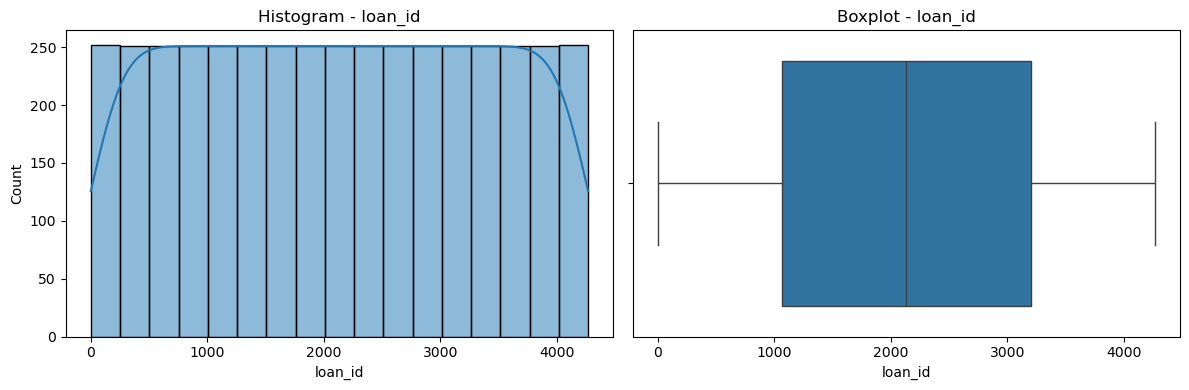

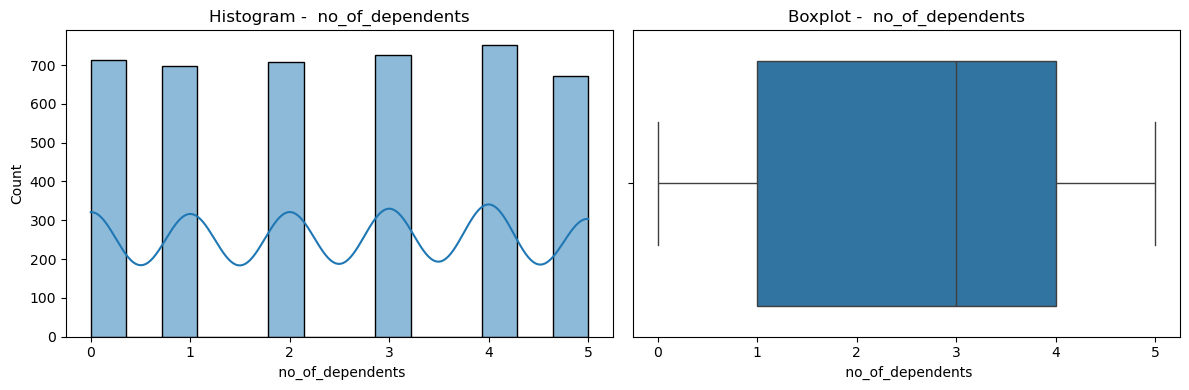

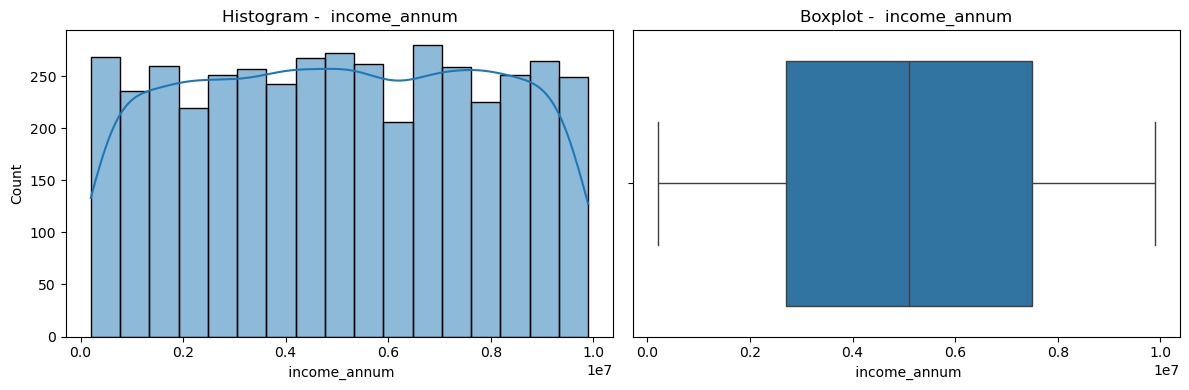

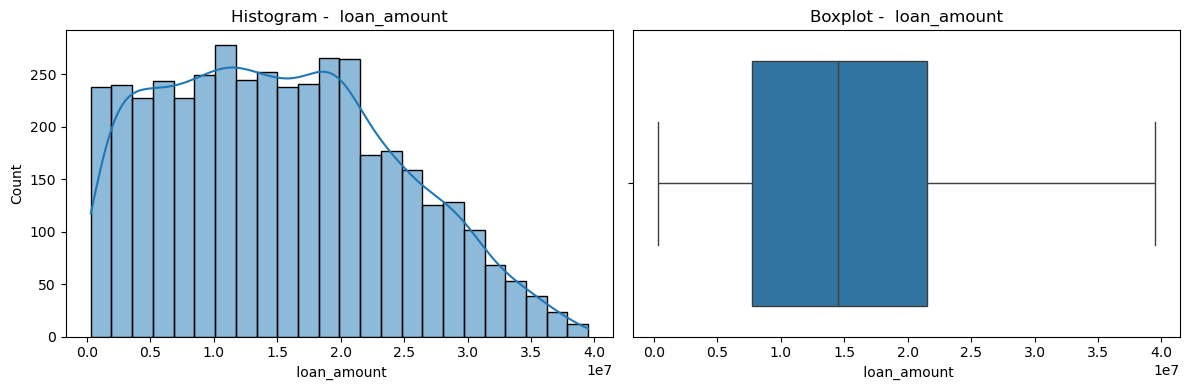

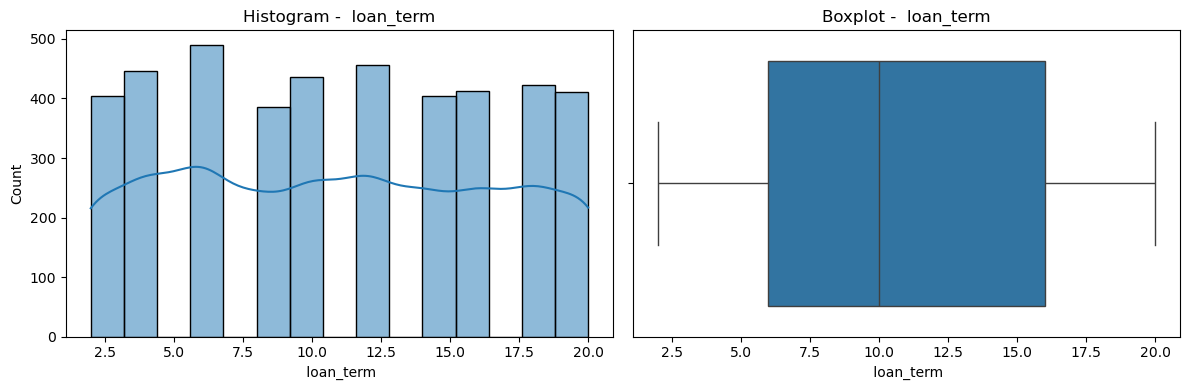

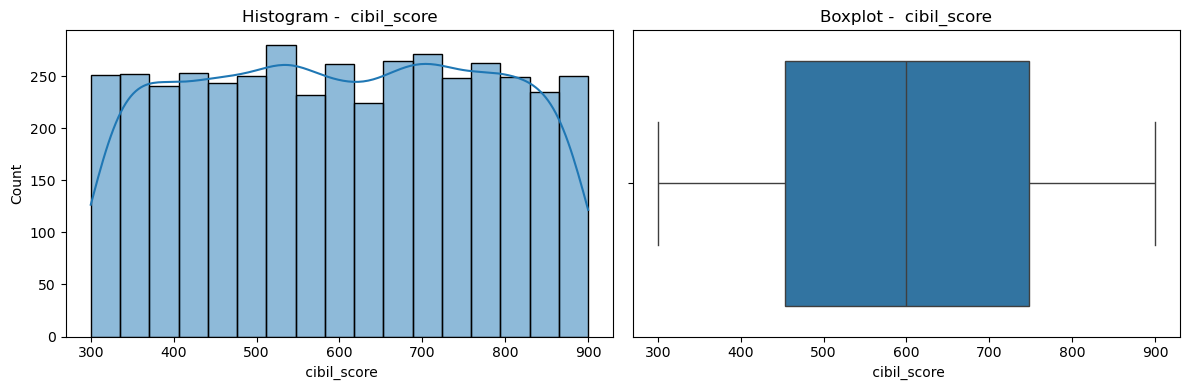

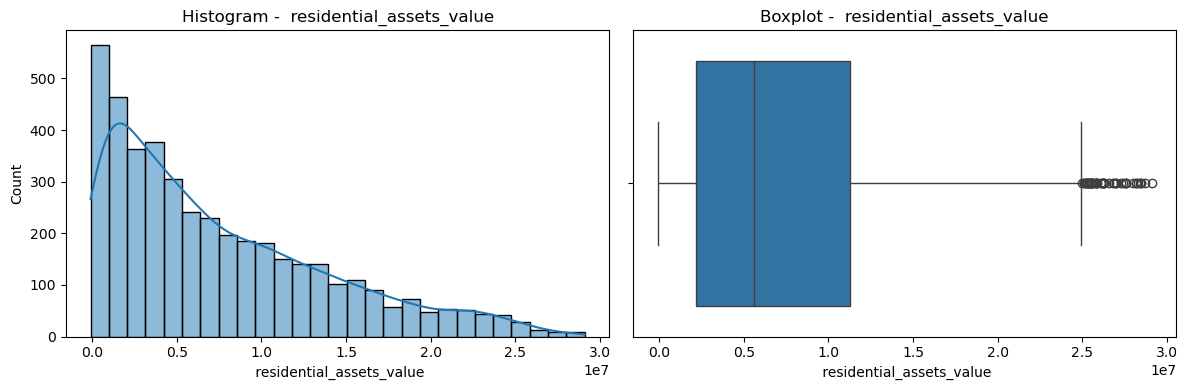

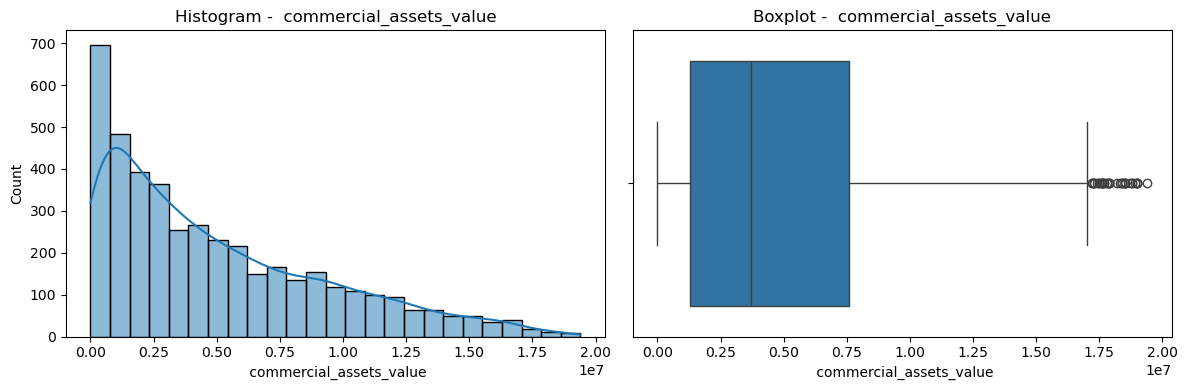

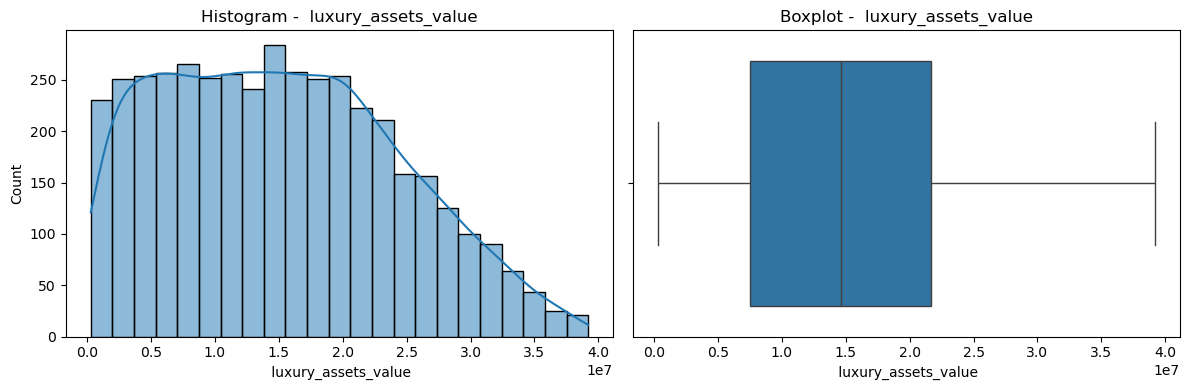

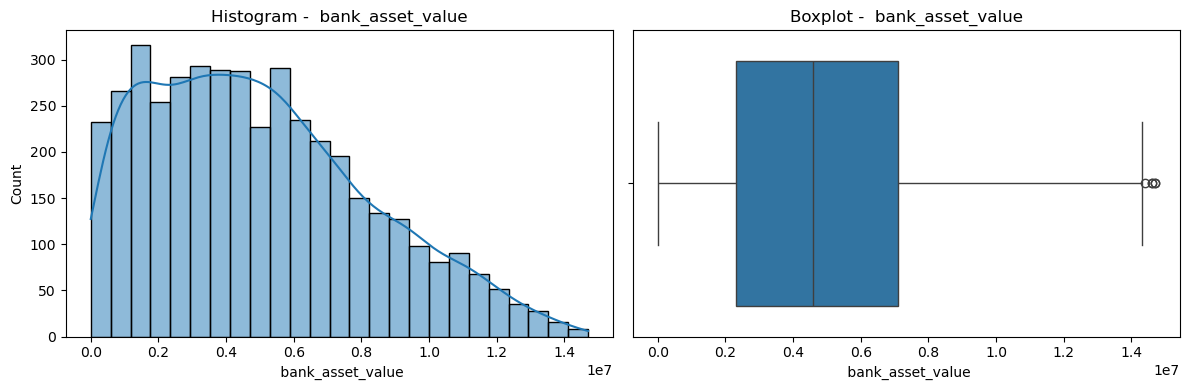

In [102]:
for col in num_cols:

    fig, ax = plt.subplots(1,2, figsize=(12,4))

    sns.histplot(df[col], kde=True, ax=ax[0])
    ax[0].set_title(f"Histogram - {col}")

    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f"Boxplot - {col}")

    plt.tight_layout()
    plt.show()

#### Heat Map and Correlation Matrix

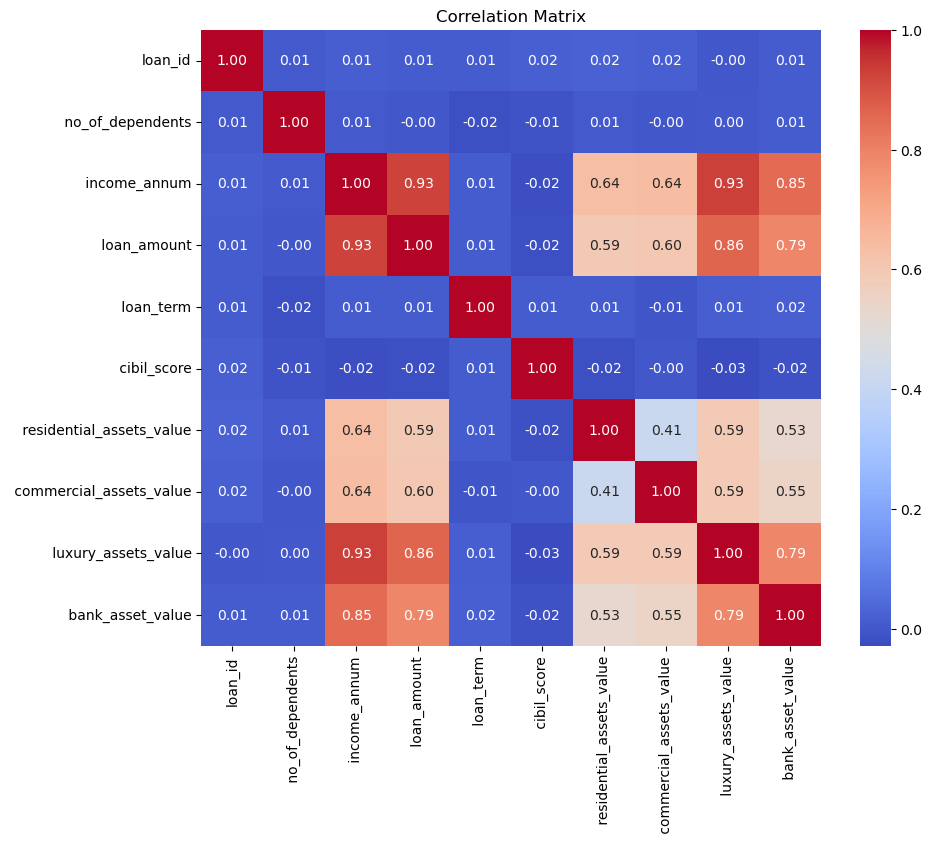

In [103]:
if len(num_cols) > 1:

    plt.figure(figsize=(10,8))

    corr = df[num_cols].corr()

    sns.heatmap(corr,
                annot=True,
                cmap="coolwarm",
                fmt=".2f")

    plt.title("Correlation Matrix")
    plt.show()


#### Pair Plot

In [104]:
if len(num_cols) <= 6:
    sns.pairplot(df[num_cols])
    plt.show()
else:
    print("\nPairplot skipped (too many numerical columns).")


Pairplot skipped (too many numerical columns).


#### Outlier Count IQR 

In [106]:
print("\nOUTLIER COUNT")

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {outliers}")


OUTLIER COUNT
loan_id: 0
 no_of_dependents: 0
 income_annum: 0
 loan_amount: 0
 loan_term: 0
 cibil_score: 0
 residential_assets_value: 52
 commercial_assets_value: 37
 luxury_assets_value: 0
 bank_asset_value: 5



Enter Target Column (Leave blank if Unsupervised):   loan_status



Detected Task : CLASSIFICATION

Class Distribution
 loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


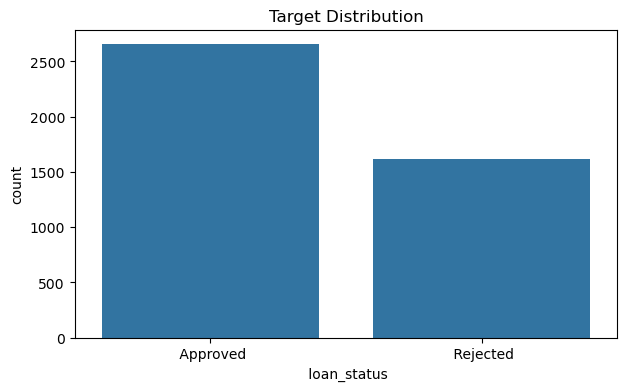

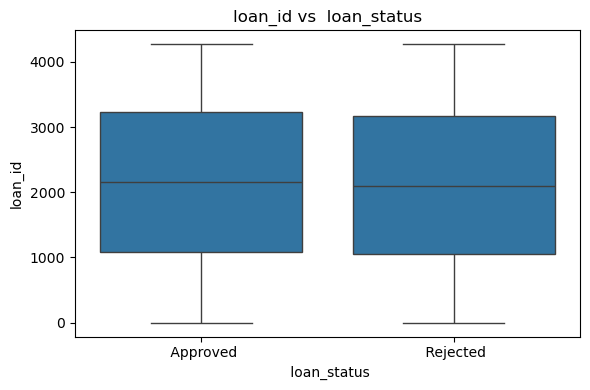

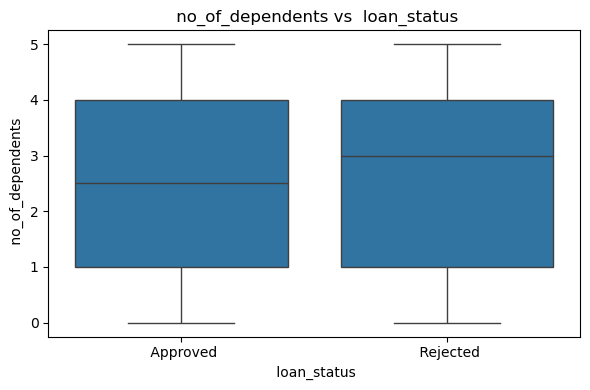

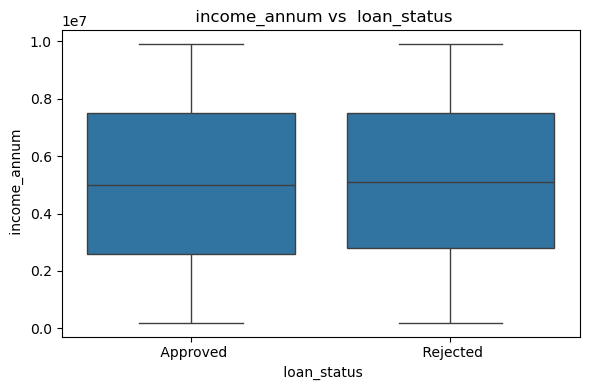

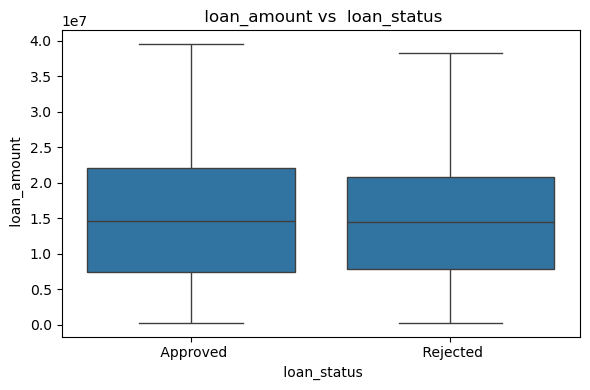

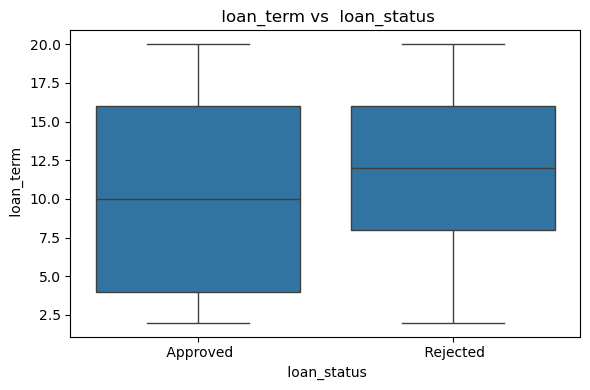

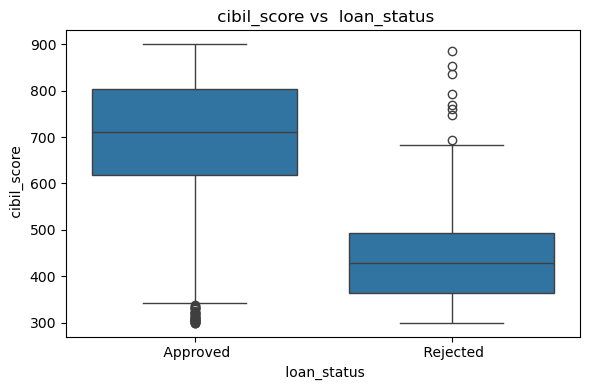

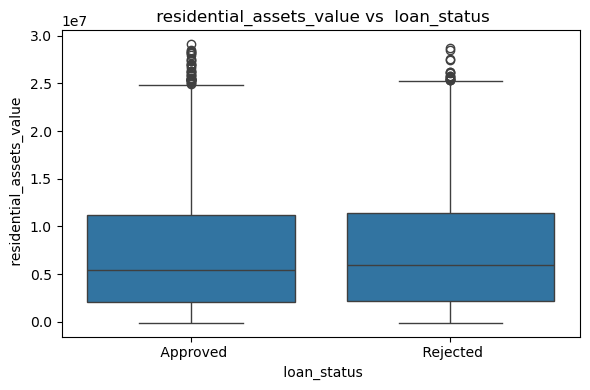

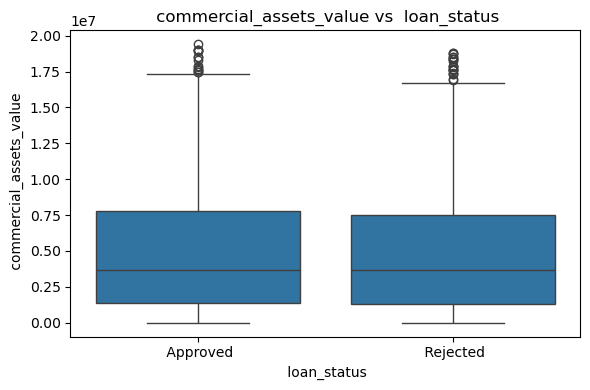

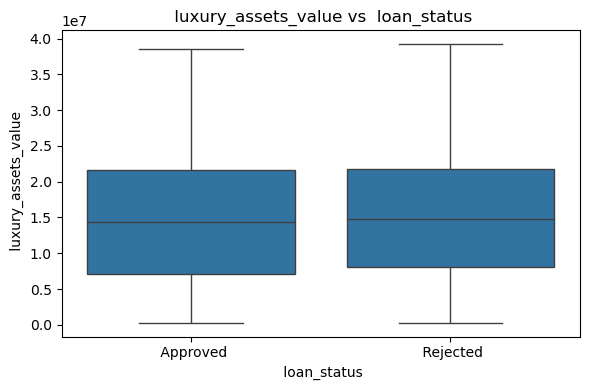

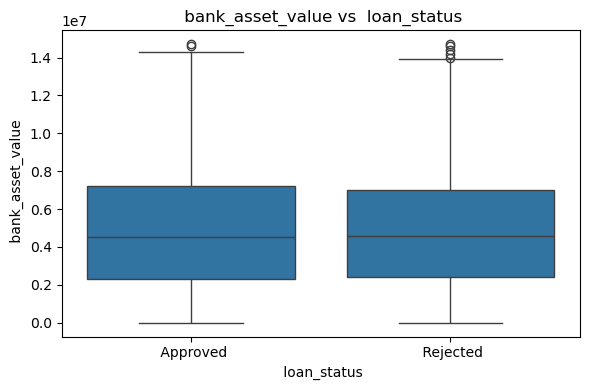

In [107]:
target = input("\nEnter Target Column (Leave blank if Unsupervised): ")
#target=input("\nEnter Target Column (Leave Blank if Unsupervised): ").strip()

if target == "":
    print("\nDataset Type : UNSUPERVISED")

elif target not in df.columns:
    print("Target column not found!")

else:

    y = df[target]

    # Detect Classification or Regression
    if y.dtype == object or y.nunique() <= 20:

        print("\nDetected Task : CLASSIFICATION")

        print("\nClass Distribution")
        print(y.value_counts())

        plt.figure(figsize=(7,4))
        sns.countplot(data=df, x=target)
        plt.title("Target Distribution")
        plt.show()

        # Numerical Features vs Target
        for col in num_cols:

            if col != target:

                plt.figure(figsize=(6,4))

                sns.boxplot(x=target,
                            y=col,
                            data=df)

                plt.title(f"{col} vs {target}")
                plt.tight_layout()
                plt.show()

    else:

        print("\nDetected Task : REGRESSION")

        plt.figure(figsize=(7,4))
        sns.histplot(df[target], kde=True)
        plt.title(target)
        plt.show()

        print("\nCorrelation with Target")
        print(df[num_cols].corr()[target].sort_values(ascending=False))

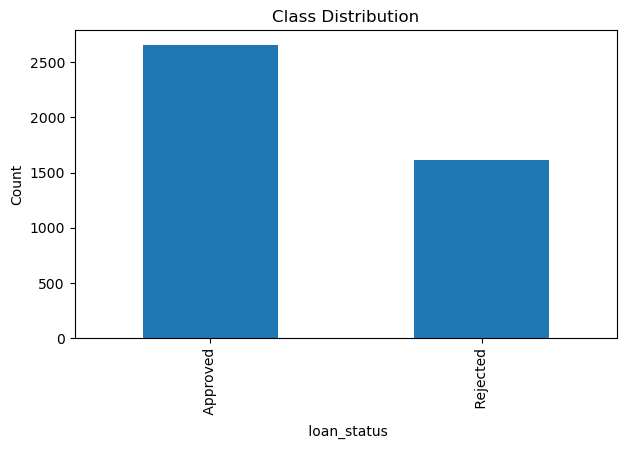

In [108]:
if target in df.columns:

    if df[target].dtype == object or df[target].nunique() <= 20:

        plt.figure(figsize=(7,4))

        df[target].value_counts().plot(kind='bar')

        plt.title("Class Distribution")

        plt.ylabel("Count")

        plt.show()

#### Skewness and Kurotosis

In [110]:
print("\nSKEWNESS")

for col in num_cols:
    print(f"{col}: {df[col].skew():.3f}")

print("\nKURTOSIS")

for col in num_cols:
    print(f"{col}: {df[col].kurtosis():.3f}")


SKEWNESS
loan_id: 0.000
 no_of_dependents: -0.018
 income_annum: -0.013
 loan_amount: 0.309
 loan_term: 0.036
 cibil_score: -0.009
 residential_assets_value: 0.978
 commercial_assets_value: 0.958
 luxury_assets_value: 0.322
 bank_asset_value: 0.561

KURTOSIS
loan_id: -1.200
 no_of_dependents: -1.257
 income_annum: -1.183
 loan_amount: -0.744
 loan_term: -1.221
 cibil_score: -1.186
 residential_assets_value: 0.185
 commercial_assets_value: 0.101
 luxury_assets_value: -0.738
 bank_asset_value: -0.397


In [64]:
print("\n" + "="*60)
print("EDA COMPLETED SUCCESSFULLY")
print("="*60)

print(f"Rows               : {df.shape[0]}")
print(f"Columns            : {df.shape[1]}")
print(f"Missing Values     : {df.isnull().sum().sum()}")
print(f"Duplicate Rows     : {duplicates}")
print(f"Numerical Columns  : {len(num_cols)}")
print(f"Categorical Columns: {len(cat_cols)}")


EDA COMPLETED SUCCESSFULLY
Rows               : 4269
Columns            : 13
Missing Values     : 0
Duplicate Rows     : 0
Numerical Columns  : 10
Categorical Columns: 3


## iv) Feature Selection (Only for Supervised Learning Datasets)

#### SelectKBest

In [121]:
X = df.drop(" loan_status", axis=1)
y = df[" loan_status"]
k = 10

le = LabelEncoder()
X[" education"] = le.fit_transform(X[" education"])
X[" self_employed"] = le.fit_transform(X[" self_employed"])

# Encode the target as well
y = le.fit_transform(y)

selector = SelectKBest(score_func=f_classif, k=k)
X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['loan_id', ' no_of_dependents', ' income_annum', ' loan_amount',
       ' loan_term', ' cibil_score', ' residential_assets_value',
       ' commercial_assets_value', ' luxury_assets_value',
       ' bank_asset_value'],
      dtype='object')


#### ANOVA

In [122]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['loan_id', ' no_of_dependents', ' income_annum', ' loan_amount',
       ' loan_term', ' cibil_score', ' residential_assets_value',
       ' commercial_assets_value', ' luxury_assets_value',
       ' bank_asset_value'],
      dtype='object')


#### Column Scores ANOVA-F Test Scores

In [123]:
import pandas as pd

scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
})

scores = scores.sort_values(by="Score", ascending=False)

print(scores)

                      Feature        Score
7                 cibil_score  6235.054591
6                   loan_term    55.225458
1            no_of_dependents     1.400600
0                     loan_id     1.334967
5                 loan_amount     1.113176
10        luxury_assets_value     1.020728
4                income_annum     0.984669
8    residential_assets_value     0.880877
9     commercial_assets_value     0.290152
11           bank_asset_value     0.196066
2                   education     0.103202
3               self_employed     0.000506


## Pipeline FULL FUNCTION